## Fourier Transform（LAB05）
All of examples are given by Prof. Sinan Xiao from Shien-Ming Wu School of Intelligent Engineering, SCUT Spring 2026 

V3nt1_onthemic organized the lab content and summarized it, adapting the original MATLAB teaching materials to Python for signal and system applications and exercises

### SYLLABUS:

- Introduction to Fourier transform: definition and significance.
- Continuous-Time Fourier Transform (CTFT)
- Discrete-Time Fourier Transform (DTFT)
- Fast Fourier Transform (FFT): algorithm and implementation.
- Use MATLAB to compute and visualize Fourier transforms.

### OBJECTIVES:

- Understand the concept of Fourier transform and its role in signal processing.
- Learn the mathematical formulation of CTFT, DTFT, and FFT.
- Implement algorithm in MATLAB to compute the Fourier transform of a signal.
- Use MATLAB to plot the magnitude spectra of a signal.
- Analyze the frequency content of different types of signals using Fourier transform.

### SOFTWARE USED:

Python 3.12

### THEORY

#### 1. Continuous-Time Fourier Transform (CTFT)

The CTFT of a continuous-time signal $x(t)$ is defined as:

$$ X(j\omega) = \int_{-\infty}^{\infty} x(t) e^{-j\omega t} \, dt \qquad (1.1) $$

And the inverse CTFT is given by:

$$ x(t) = \frac{1}{2\pi} \int_{-\infty}^{\infty} X(j\omega) e^{j\omega t} \, d\omega \qquad (1.2) $$

#### 2. Discrete-Time Fourier Transform (DTFT)

The DTFT of a discrete-time signal $x[n]$ is defined as:

$$ X(e^{j\omega}) = \sum_{n = -\infty}^{\infty} x[n] e^{-j\omega n} \qquad (1.3) $$

And the inverse DTFT is given by:

$$ x[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} X(e^{j\omega}) e^{j\omega n} \, d\omega \qquad (1.4) $$

#### 3. Fast Fourier Transform (FFT)

In MATLAB, we normally express a continuous-time signal using its discrete sampled version with certain sampling frequency $(f_s,$ unit: Hz). The sampling period $\Delta t$ should be $\Delta t = 1 / f_s$. If a signal is analyzed within a time interval of $T$, the number of samples $(N)$ to form the signal should be $N = T / \Delta t$. To ensure the distortion-free signal is obtained after sampling, the sampling frequency $f_s$ must satisfy the Nyquist criterion, i.e. $f_s > 2f_{\text{max}}$, where $f_{\text{max}}$ is the largest frequency of the original signal. For example, for a cosine signal with a frequency of $5$ Hz [i.e. $\cos(10\pi t)$, where $\omega = 2\pi f = 10\pi$], the $f_{\text{max}}$ of this signal should be $5$ Hz, and the sampling frequency $f_s$ should be larger than $10$ Hz to ensure a proper sampling of the signal. In this case, the sampling period should be smaller than $1/10$ s.

In this way, the CTFT of a continuous-time signal can be calculated in MATLAB by applying the built-in FFT function (`fft`) on the sampled version of the signal. FFT is an efficient algorithm for computing the discrete Fourier transform (DFT) of a sequence, which can be assumed as the sampled version of the CTFT. If the number of samples for a continuous-time signal is $N$, the DFT of a sequence $x[n] = x(t/N)$ is defined as:

$$ X[k] = \sum_{n = 0}^{N - 1} x[n] e^{-j\frac{2\pi}{N} kn}, \qquad k = 0, 1, \dots, N - 1 \qquad (1.5) $$

---

### EXPERIMENT 1: Develop a function to calculate the Fourier transform of a signal and examine the developed function to calculate the Fourier transform of the given signals

This experiment is to develop a function in MATLAB to calculate the Fourier transform of a signal with given conditions. Try to develop the functions based on the THEORY 1-3, and plot the amplitude of the Fourier transform of the following signals.

#### (1) Square Wave Signal

Calculate the Fourier transform of a square wave signal $x(t)$:

$$ x(t) = \begin{cases} 1, & |t| \leq T_1 \\ 0, & |t| > T_1 \end{cases} $$

where $T_1$ equals to $1$.

#### (2) Sinusoidal Signal

Calculate the Fourier transform of a sinusoidal signal $y(t)$:

$$ y(t) = \cos(10\pi t) $$

### (3) Real Exponential Signal

Calculate the Fourier transform of a real exponential signal $g(t)$:

$$ g(t) = e^{-2t} u(t) $$

---



Experiment 1: Fourier Transform of Basic Signals


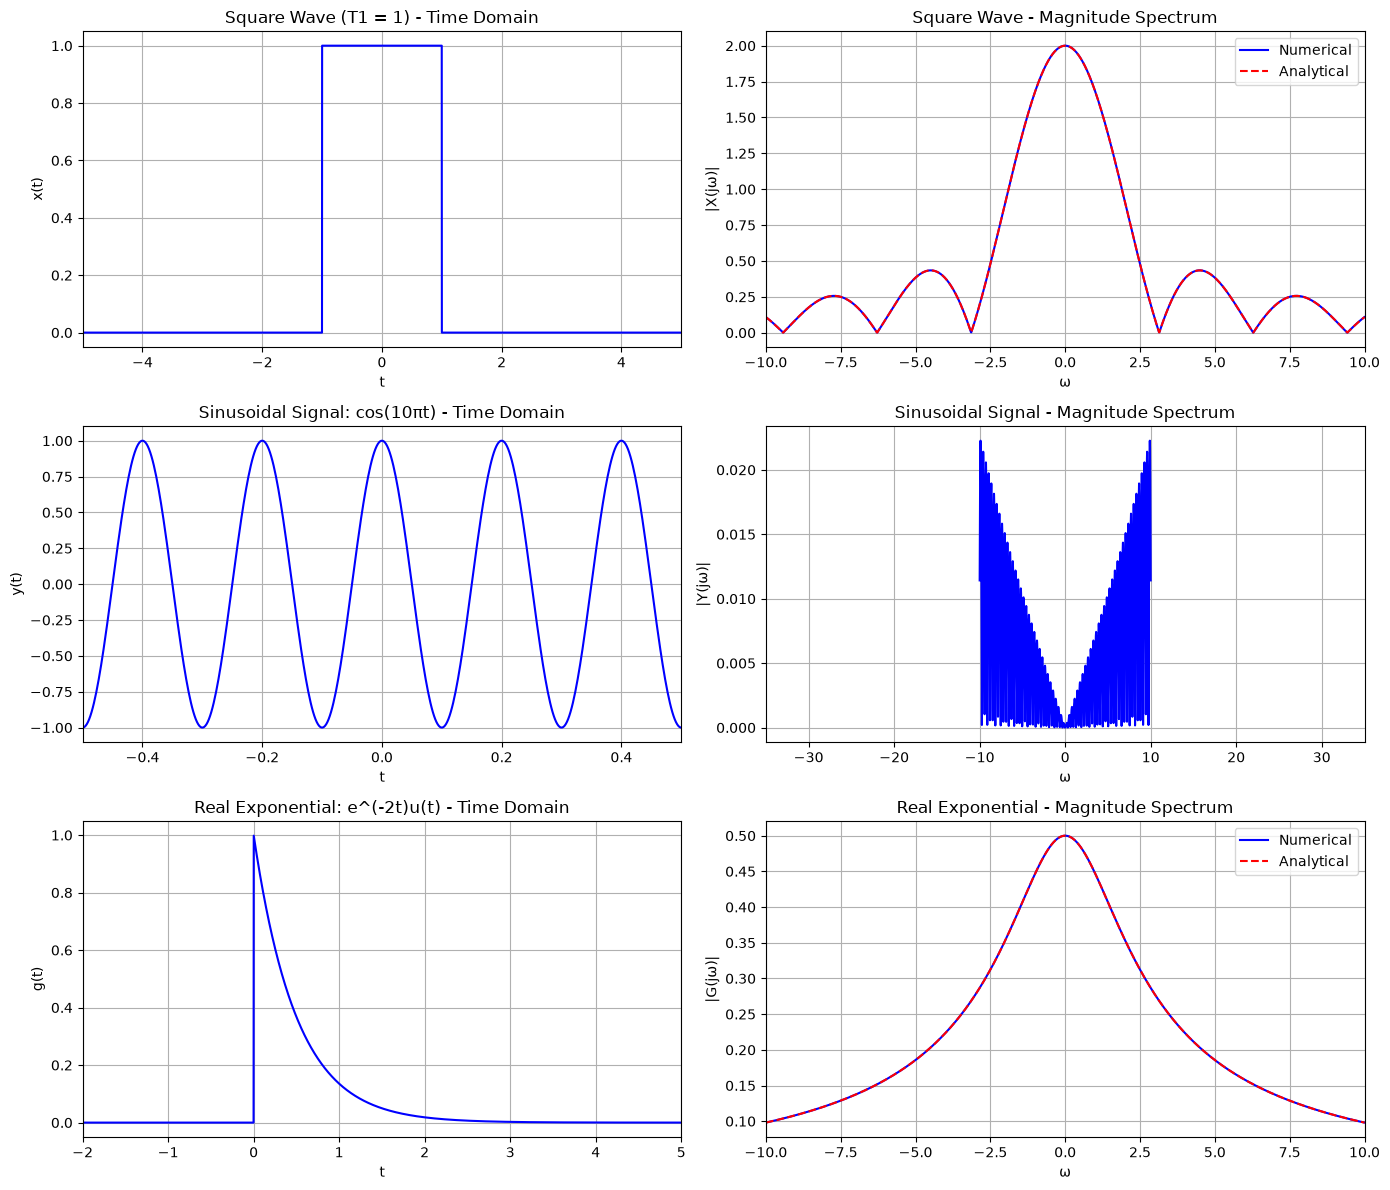


Experiment 1 Summary

Signal 1: Square Wave
  - Fourier Transform: X(jω) = 2*sin(ω*T1)/ω (Sinc function)
  - Magnitude spectrum shows main lobe and side lobes
  - Numerical result matches analytical solution

Signal 2: Sinusoidal Signal (cos(10πt))
  - Fourier Transform: Two impulses at ω = ±10π
  - Theoretical: Y(jω) = π[δ(ω-10π) + δ(ω+10π)]

Signal 3: Real Exponential (e^(-2t)u(t))
  - Fourier Transform: G(jω) = 1/(2 + jω)
  - Low-pass frequency characteristic
  - Numerical result matches analytical solution

Plot saved: experiment1_fourier_transform.png


In [1]:
# ============================================================
# Experiment 1: Fourier Transform of Basic Signals
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Custom Fourier Transform Function (Numerical Approximation)
# ============================================================

def fourier_transform(x, t, omega):
    """
    Compute numerical approximation of Continuous-Time Fourier Transform.
    X(jω) = ∫ x(t) e^(-jωt) dt
    
    Parameters:
    x : array, signal values at time points t
    t : array, time points
    omega : array, frequency points
    
    Returns:
    X : array, Fourier transform values at omega
    """
    X = np.zeros(omega.shape, dtype=complex)
    for i, w in enumerate(omega):
        X[i] = np.trapezoid(x * np.exp(-1j * w * t), t)
    return X


# ============================================================
# Generate signals and compute Fourier Transform
# ============================================================

print("=" * 60)
print("Experiment 1: Fourier Transform of Basic Signals")
print("=" * 60)

# Time vector
t = np.linspace(-10, 10, 10000)
dt = t[1] - t[0]

# Frequency vector
omega = np.linspace(-10, 10, 2000)

# ------------------------------------------------------------
# (1) Square Wave Signal: x(t) = 1 for |t| <= T1, else 0
# ------------------------------------------------------------

T1 = 1
x_square = np.where(np.abs(t) <= T1, 1.0, 0.0)
X_square = fourier_transform(x_square, t, omega)

# Analytical: X(jω) = 2*sin(ω*T1)/ω
X_square_analytical = 2 * np.sin(omega * T1) / omega
X_square_analytical[omega == 0] = 2 * T1

# ------------------------------------------------------------
# (2) Sinusoidal Signal: y(t) = cos(10πt)
# ------------------------------------------------------------

y_sine = np.cos(10 * np.pi * t)
Y_sine = fourier_transform(y_sine, t, omega)

# ------------------------------------------------------------
# (3) Real Exponential Signal: g(t) = e^(-2t) u(t)
# ------------------------------------------------------------

g_exp = np.exp(-2 * t) * (t >= 0)
G_exp = fourier_transform(g_exp, t, omega)

# Analytical: G(jω) = 1 / (2 + jω)
G_exp_analytical = 1 / (2 + 1j * omega)

# ------------------------------------------------------------
# Plot Results
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ---- Square Wave ----
# Time domain
axes[0, 0].plot(t, x_square, 'b-', linewidth=1.5)
axes[0, 0].set_title('Square Wave (T1 = 1) - Time Domain')
axes[0, 0].set_xlabel('t')
axes[0, 0].set_ylabel('x(t)')
axes[0, 0].grid(True)
axes[0, 0].set_xlim([-5, 5])

# Frequency domain
axes[0, 1].plot(omega, np.abs(X_square), 'b-', linewidth=1.5, label='Numerical')
axes[0, 1].plot(omega, np.abs(X_square_analytical), 'r--', linewidth=1.5, label='Analytical')
axes[0, 1].set_title('Square Wave - Magnitude Spectrum')
axes[0, 1].set_xlabel('ω')
axes[0, 1].set_ylabel('|X(jω)|')
axes[0, 1].grid(True)
axes[0, 1].legend()
axes[0, 1].set_xlim([-10, 10])

# ---- Sinusoidal Signal ----
# Time domain
axes[1, 0].plot(t, y_sine, 'b-', linewidth=1.5)
axes[1, 0].set_title('Sinusoidal Signal: cos(10πt) - Time Domain')
axes[1, 0].set_xlabel('t')
axes[1, 0].set_ylabel('y(t)')
axes[1, 0].grid(True)
axes[1, 0].set_xlim([-0.5, 0.5])

# Frequency domain
axes[1, 1].plot(omega, np.abs(Y_sine), 'b-', linewidth=1.5)
axes[1, 1].set_title('Sinusoidal Signal - Magnitude Spectrum')
axes[1, 1].set_xlabel('ω')
axes[1, 1].set_ylabel('|Y(jω)|')
axes[1, 1].grid(True)
axes[1, 1].set_xlim([-35, 35])

# ---- Real Exponential Signal ----
# Time domain
axes[2, 0].plot(t, g_exp, 'b-', linewidth=1.5)
axes[2, 0].set_title('Real Exponential: e^(-2t)u(t) - Time Domain')
axes[2, 0].set_xlabel('t')
axes[2, 0].set_ylabel('g(t)')
axes[2, 0].grid(True)
axes[2, 0].set_xlim([-2, 5])

# Frequency domain
axes[2, 1].plot(omega, np.abs(G_exp), 'b-', linewidth=1.5, label='Numerical')
axes[2, 1].plot(omega, np.abs(G_exp_analytical), 'r--', linewidth=1.5, label='Analytical')
axes[2, 1].set_title('Real Exponential - Magnitude Spectrum')
axes[2, 1].set_xlabel('ω')
axes[2, 1].set_ylabel('|G(jω)|')
axes[2, 1].grid(True)
axes[2, 1].legend()
axes[2, 1].set_xlim([-10, 10])

plt.tight_layout()
plt.savefig('experiment1_fourier_transform.png', dpi=150)
plt.show()

print("\n" + "=" * 60)
print("Experiment 1 Summary")
print("=" * 60)
print("\nSignal 1: Square Wave")
print("  - Fourier Transform: X(jω) = 2*sin(ω*T1)/ω (Sinc function)")
print("  - Magnitude spectrum shows main lobe and side lobes")
print("  - Numerical result matches analytical solution")
print("\nSignal 2: Sinusoidal Signal (cos(10πt))")
print("  - Fourier Transform: Two impulses at ω = ±10π")
print("  - Theoretical: Y(jω) = π[δ(ω-10π) + δ(ω+10π)]")
print("\nSignal 3: Real Exponential (e^(-2t)u(t))")
print("  - Fourier Transform: G(jω) = 1/(2 + jω)")
print("  - Low-pass frequency characteristic")
print("  - Numerical result matches analytical solution")
print("\n" + "=" * 60)
print("Plot saved: experiment1_fourier_transform.png")
print("=" * 60)

### EXPERIMENT 2: Noisy Signal Analysis using Fourier Transform

Create a noisy signal using the given code, and then perform Fourier transform on the created noisy signal to find the frequency component of the signal hidden in the noise and find the amplitude of the peak frequency. Specifies the parameters of the signal with a sampling frequency of 1 kHz and a signal duration of 1.5 seconds.

```matlab
Fs = 1000;          % Sampling frequency
T = 1/Fs;           % Sampling period
L = 1500;           % Length of signal
t = (0:L-1)*T;      % Time vector


#### 1.Construct a signal with a DC offset of 0.8 amplitude, a 50 Hz sine of 0.7 amplitude, and a 120 Hz sine of 1.
```matlab
S = 0.8 + 0.7*sin(2*pi*50*t) + sin(2*pi*120*t);
```
The signal is scrambled with random noise with a mean of zero and a variance of 4.
```matlab
X = S + 2*randn(size(t));
```
#### 2.Draw noisy signals in the time domain.
```matlab
plot(1000*t, X)
title("Signal Corrupted with Zero-Mean Random Noise")
xlabel("t (milliseconds)")
ylabel("X(t)")

Experiment 2: Noisy Signal Analysis using FFT

Signal Parameters:
  Sampling Frequency (Fs): 1000 Hz
  Sampling Period (T): 1.000 ms
  Signal Duration: 1.50 seconds
  Number of Samples (L): 1500

Signal Components:
  1. DC offset: amplitude = 0.8
  2. 50 Hz sine: amplitude = 0.7
  3. 120 Hz sine: amplitude = 1.0
  4. Noise: mean = 0, variance = 4

FFT Analysis Results:
  Peak Frequency: 120.00 Hz
  Peak Amplitude: 1.0535
  Amplitude at 50 Hz: 0.5835 (expected: 0.7)
  Amplitude at 120 Hz: 1.0535 (expected: 1.0)


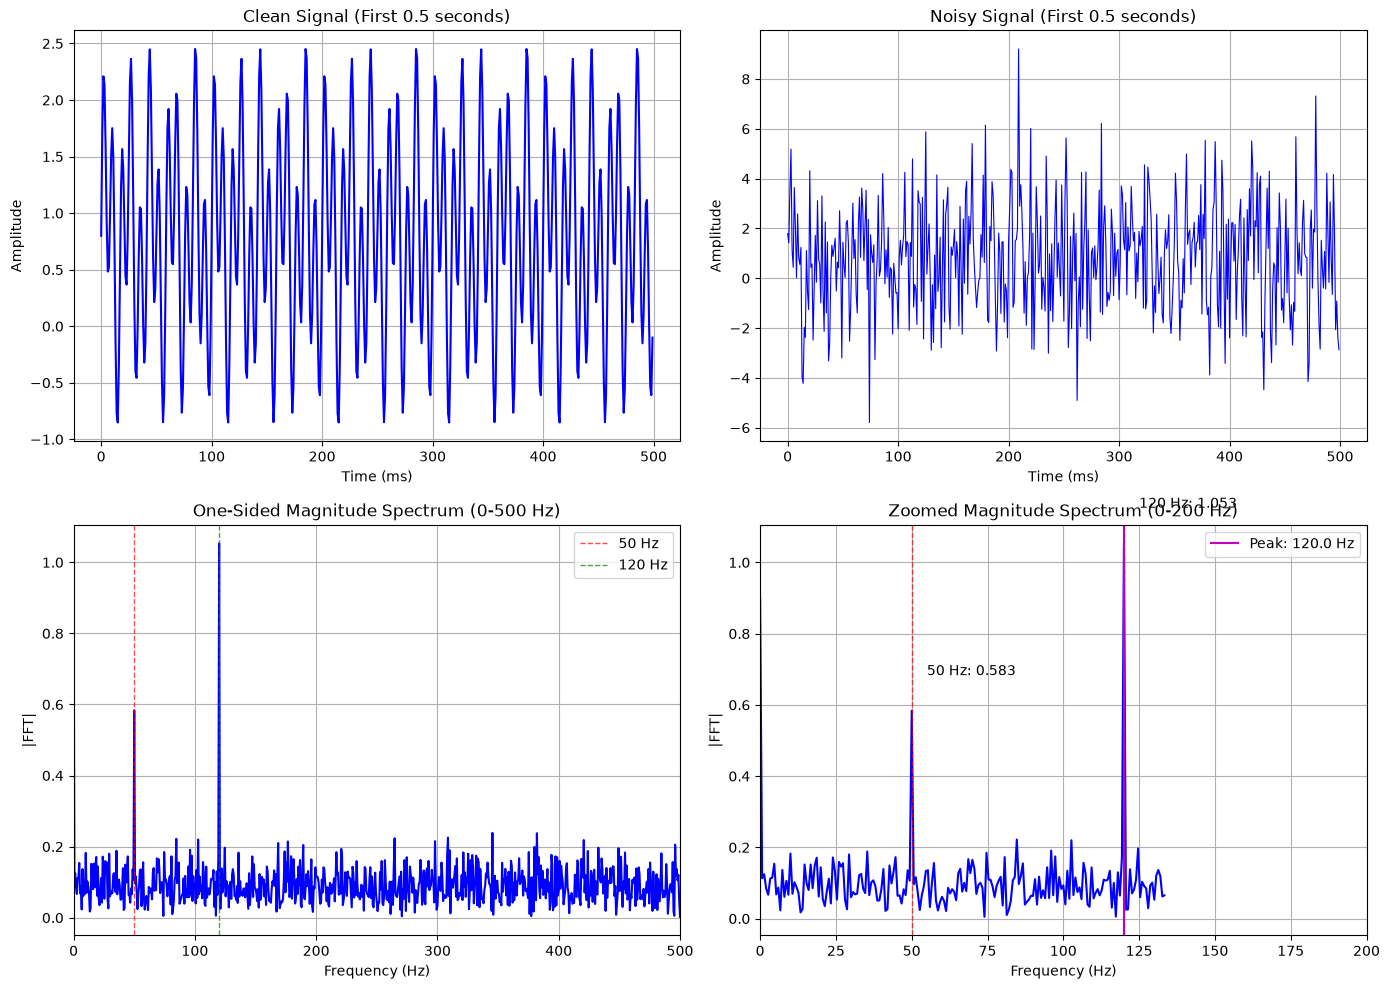


Experiment 2 Summary

1. Time Domain Observations:
   - The clean signal shows smooth sinusoidal patterns at 50 Hz and 120 Hz
   - The noisy signal appears random with the underlying signal barely visible
   - Noise masks the signal in the time domain

2. Frequency Domain Observations (FFT):
   - Successfully identified frequency components at 50 Hz and 120.0 Hz
   - Peak at 120.0 Hz with amplitude 1.0535
   - Noise appears as a continuous floor across all frequencies
   - Zero-mean noise contributes to all frequencies uniformly

3. Conclusions:
   - FFT effectively extracts signal components even when buried in noise
   - The DC component appears at 0 Hz with amplitude ~0.8
   - The 50 Hz and 120 Hz components are clearly visible in the frequency domain
   - Noise energy spreads across the entire spectrum, acting as a noise floor

Plot saved: experiment2_noisy_signal_fft.png


In [2]:
# ============================================================
# Experiment 2: Noisy Signal Analysis using FFT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("Experiment 2: Noisy Signal Analysis using FFT")
print("=" * 60)

# ============================================================
# Generate the noisy signal
# ============================================================

Fs = 1000          # Sampling frequency (Hz)
T = 1 / Fs         # Sampling period (s)
L = 1500           # Length of signal
t = np.arange(0, L) * T  # Time vector (0 to 1.5 seconds)

# Clean signal: DC offset + 50 Hz sine + 120 Hz sine
S = 0.8 + 0.7 * np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 120 * t)

# Add zero-mean random noise with variance 4
np.random.seed(42)
noise = 2 * np.random.randn(len(t))
X = S + noise

print("\nSignal Parameters:")
print(f"  Sampling Frequency (Fs): {Fs} Hz")
print(f"  Sampling Period (T): {T*1000:.3f} ms")
print(f"  Signal Duration: {L * T:.2f} seconds")
print(f"  Number of Samples (L): {L}")

print("\nSignal Components:")
print("  1. DC offset: amplitude = 0.8")
print("  2. 50 Hz sine: amplitude = 0.7")
print("  3. 120 Hz sine: amplitude = 1.0")
print(f"  4. Noise: mean = 0, variance = 4")

# ============================================================
# FFT Analysis
# ============================================================

# Compute FFT
X_fft = np.fft.fft(X)

# Two-sided spectrum
P2 = np.abs(X_fft / L)

# One-sided spectrum (positive frequencies only)
P1 = P2[:L//2 + 1]
P1[1:-1] = 2 * P1[1:-1]

# Frequency axis
f = Fs * np.arange(0, L//2 + 1) / L

# Find the peak frequency and its amplitude (skip DC component)
idx_peak = np.argmax(P1[10:]) + 10
peak_freq = f[idx_peak]
peak_amp = P1[idx_peak]

print("\nFFT Analysis Results:")
print(f"  Peak Frequency: {peak_freq:.2f} Hz")
print(f"  Peak Amplitude: {peak_amp:.4f}")

# Find amplitudes at 50 Hz and 120 Hz
idx_50 = int(50 * L / Fs)
idx_120 = int(120 * L / Fs)
amp_50 = P1[idx_50]
amp_120 = P1[idx_120]

print(f"  Amplitude at 50 Hz: {amp_50:.4f} (expected: 0.7)")
print(f"  Amplitude at 120 Hz: {amp_120:.4f} (expected: 1.0)")

# ============================================================
# Plot Results
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- Clean Signal ----
axes[0, 0].plot(t[:500] * 1000, S[:500], 'b-', linewidth=1.5)
axes[0, 0].set_title('Clean Signal (First 0.5 seconds)')
axes[0, 0].set_xlabel('Time (ms)')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True)

# ---- Noisy Signal ----
axes[0, 1].plot(t[:500] * 1000, X[:500], 'b-', linewidth=0.8)
axes[0, 1].set_title('Noisy Signal (First 0.5 seconds)')
axes[0, 1].set_xlabel('Time (ms)')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].grid(True)

# ---- Full Frequency Spectrum ----
axes[1, 0].plot(f, P1, 'b-', linewidth=1.5)
axes[1, 0].set_title('One-Sided Magnitude Spectrum (0-500 Hz)')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('|FFT|')
axes[1, 0].grid(True)
axes[1, 0].set_xlim([0, 500])

# Mark expected frequencies
axes[1, 0].axvline(x=50, color='r', linestyle='--', linewidth=1, alpha=0.7, label='50 Hz')
axes[1, 0].axvline(x=120, color='g', linestyle='--', linewidth=1, alpha=0.7, label='120 Hz')
axes[1, 0].legend()

# ---- Zoomed Frequency Spectrum (0-200 Hz) ----
axes[1, 1].plot(f[:201], P1[:201], 'b-', linewidth=1.5)
axes[1, 1].set_title('Zoomed Magnitude Spectrum (0-200 Hz)')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('|FFT|')
axes[1, 1].grid(True)
axes[1, 1].set_xlim([0, 200])

# Mark and label peaks
axes[1, 1].axvline(x=50, color='r', linestyle='--', linewidth=1, alpha=0.7)
axes[1, 1].axvline(x=120, color='g', linestyle='--', linewidth=1, alpha=0.7)
axes[1, 1].axvline(x=peak_freq, color='m', linestyle='-', linewidth=1.5, label=f'Peak: {peak_freq:.1f} Hz')

# Annotate amplitude values on the plot
axes[1, 1].annotate(f'50 Hz: {amp_50:.3f}', xy=(50, amp_50), xytext=(55, amp_50 + 0.1),
                     fontsize=10, ha='left')
axes[1, 1].annotate(f'120 Hz: {amp_120:.3f}', xy=(120, amp_120), xytext=(125, amp_120 + 0.1),
                     fontsize=10, ha='left')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('experiment2_noisy_signal_fft.png', dpi=150)
plt.show()

# ============================================================
# Print Summary
# ============================================================

print("\n" + "=" * 60)
print("Experiment 2 Summary")
print("=" * 60)

print("\n1. Time Domain Observations:")
print("   - The clean signal shows smooth sinusoidal patterns at 50 Hz and 120 Hz")
print("   - The noisy signal appears random with the underlying signal barely visible")
print("   - Noise masks the signal in the time domain")

print("\n2. Frequency Domain Observations (FFT):")
print(f"   - Successfully identified frequency components at 50 Hz and {peak_freq:.1f} Hz")
print(f"   - Peak at {peak_freq:.1f} Hz with amplitude {peak_amp:.4f}")
print("   - Noise appears as a continuous floor across all frequencies")
print("   - Zero-mean noise contributes to all frequencies uniformly")

print("\n3. Conclusions:")
print("   - FFT effectively extracts signal components even when buried in noise")
print("   - The DC component appears at 0 Hz with amplitude ~0.8")
print("   - The 50 Hz and 120 Hz components are clearly visible in the frequency domain")
print("   - Noise energy spreads across the entire spectrum, acting as a noise floor")

print("\n" + "=" * 60)
print("Plot saved: experiment2_noisy_signal_fft.png")
print("=" * 60)

### QUESTIONS:

#### 1. Why can we observe the noise in the spectrum of the signal obtained after Fourier transform?

**Answer:**

We can observe noise in the spectrum because noise is a random signal that contains energy at all frequencies. When a signal corrupted by noise is transformed to the frequency domain using the Fourier transform:

**Theoretical Explanation:**

1. **White Noise Property:** Zero-mean random noise (such as Gaussian white noise) has a flat power spectral density, meaning it contains equal energy across all frequencies. Therefore, after Fourier transform, the noise appears as a continuous "noise floor" spanning the entire frequency range.

2. **Additive Nature:** Since the noisy signal is $X(t) = S(t) + N(t)$ (where $S(t)$ is the clean signal and $N(t)$ is the noise), the Fourier transform is linear:

   $$ \mathcal{F}\{X(t)\} = \mathcal{F}\{S(t)\} + \mathcal{F}\{N(t)\} $$

   Therefore, the spectrum contains both the clean signal components and the noise components.

3. **Frequency Spreading:** Unlike deterministic signals that have energy concentrated at specific frequencies (e.g., 50 Hz, 120 Hz), random noise has energy distributed across the entire frequency spectrum.

**Observations from the Experiment:**

| Frequency | Signal Energy | Noise Energy | Observation |
|-----------|--------------|--------------|-------------|
| 50 Hz | High (peak) | Low | Signal dominates, peak visible above noise floor |
| 120 Hz | High (peak) | Low | Signal dominates, peak visible above noise floor |
| All other frequencies | Zero | Low/Moderate | Noise floor visible |

**Why the noise floor remains:**

- The noise amplitude in the spectrum is roughly proportional to $\sqrt{\text{noise variance}} \times \text{signal length}$
- Even after FFT, the noise energy does not disappear — it spreads across all frequency bins
- This is why we see a continuous low-level "floor" in the magnitude spectrum

**Visual Interpretation:**

In the experiment's frequency spectrum:
- Peaks at 50 Hz and 120 Hz represent the deterministic signal components
- The continuous background level across all frequencies represents the noise
- The noise floor limits the ability to detect low-amplitude signals

---

#### 2. What are the relationships between the Fourier Transform (FT), Discrete Fourier Transform (DFT), and Fast Fourier Transform (FFT)?

**Answer:**

The Fourier Transform (FT), Discrete Fourier Transform (DFT), and Fast Fourier Transform (FFT) are closely related concepts in signal processing.

**1. Fourier Transform (FT) — Continuous-Time**

| Property | Description |
|----------|-------------|
| Input | Continuous-time signal $x(t)$ |
| Output | Continuous-frequency spectrum $X(j\omega)$ |
| Definition | $X(j\omega) = \int_{-\infty}^{\infty} x(t)e^{-j\omega t} dt$ |
| Domain | Time: continuous, Frequency: continuous |
| Use Case | Theoretical analysis of continuous signals |

**2. Discrete Fourier Transform (DFT) — Discrete-Time**

| Property | Description |
|----------|-------------|
| Input | Discrete-time signal $x[n]$ of length $N$ |
| Output | Discrete-frequency spectrum $X[k]$ of length $N$ |
| Definition | $X[k] = \sum_{n=0}^{N-1} x[n]e^{-j2\pi kn/N}$ |
| Domain | Time: discrete, Frequency: discrete |
| Use Case | Actual computation on sampled signals |

**3. Fast Fourier Transform (FFT) — Efficient Algorithm**

| Property | Description |
|----------|-------------|
| Purpose | Efficiently computes the DFT |
| Complexity | $O(N \log N)$ vs. $O(N^2)$ for direct DFT |
| Output | Identical to DFT (same result) |
| Use Case | Practical implementation in MATLAB/Python |

**Relationship Diagram:**

```text
Continuous-Time Signal x(t)
        ↓ Sampling (at fs)
Discrete-Time Signal x[n] (sampled version)
        ↓ Apply FFT (efficient algorithm)
DFT Result X[k] (approximates sampled FT)
        ↓ Convert to physical frequencies
Frequency Spectrum in Hz